In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import( accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score, confusion_matrix)
from sklearn.metrics import ConfusionMatrixDisplay

In [43]:
data=pd.read_csv("loan_approval_dataset.csv")
df=pd.DataFrame(data)

In [44]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [14]:
df.shape

(4269, 13)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [17]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
4264    False
4265    False
4266    False
4267    False
4268    False
Length: 4269, dtype: bool>

In [46]:
df.columns = df.columns.str.strip()

In [47]:
df['education'] = df['education'].str.strip()

df['education'] = df['education'].map({
    'Graduate': 1,
    'Not Graduate': 0
})
df['self_employed'] = df['self_employed'].str.strip()
df['self_employed'] = df['self_employed'].map({
    'Yes': 1,
    'No': 0
})

In [48]:
df['loan_status'] = df['loan_status'].str.strip()

df['loan_status_encoded'] = df['loan_status'].map({
    'Approved': 1,
    'Rejected': 0
})

In [49]:
df.head()


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_status_encoded
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected,0


In [50]:
df['loan_status_encoded'].value_counts()

loan_status_encoded
1    2656
0    1613
Name: count, dtype: int64

In [78]:
# Features
x = df[['no_of_dependents', 'education', 'self_employed',
        'income_annum', 'loan_amount', 'loan_term',
        'cibil_score', 'residential_assets_value',
        'commercial_assets_value', 'luxury_assets_value',
        'bank_asset_value']]

# Target
y = df['loan_status_encoded']

In [88]:
from sklearn.impute import SimpleImputer
import pandas as pd

imputer = SimpleImputer(strategy='median')
#imputer is ude to fill the missing values with the median of the column 

x = pd.DataFrame(
    imputer.fit_transform(x),
    columns=X.columns
)

In [89]:
x_train, x_test, y_train, y_test= train_test_split(x,y,test_size=0.2,stratify=y,random_state=42)

In [104]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#StandardScaler is used because the features have different scales

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [97]:
model=LogisticRegression(max_iter=100)
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [98]:
y_pred=model.predict(x_test)
y_pred_prob = model.predict_proba(x_test)[:,1]
#it provides the probability of approval of the loan, required by the roc curve

In [99]:
print("-"*50)
print('Accuracy:', accuracy_score(y_test,y_pred))
print('Precision: ', precision_score(y_test,y_pred))
print('Recall: ', recall_score(y_test,y_pred))
print('F1 Score: ', f1_score(y_test,y_pred))
print('ROC AUC Score: ', roc_auc_score(y_test,y_pred))
print("-"*50)

--------------------------------------------------
Accuracy: 0.9133489461358314
Precision:  0.9208103130755064
Recall:  0.9416195856873822
F1 Score:  0.931098696461825
ROC AUC Score:  0.9042463253514311
--------------------------------------------------


[[280  43]
 [ 31 500]]


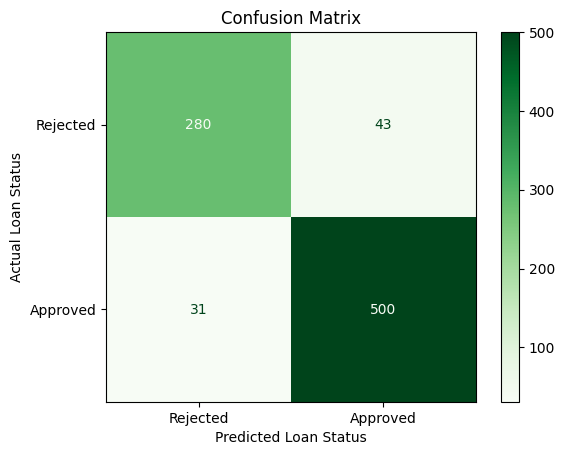

In [100]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Rejected', 'Approved'],
    cmap='Greens'
)

plt.xlabel("Predicted Loan Status")
plt.ylabel("Actual Loan Status")
plt.title("Confusion Matrix")

plt.show()

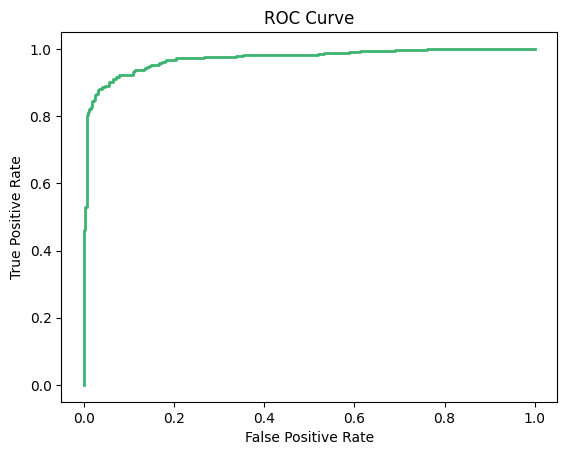

In [101]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.plot(fpr, tpr, color='mediumseagreen', linewidth=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.show()

In [103]:
sample_data = [[
    2,          # no_of_dependents
    1,          # education(Non Graduate-0, Graduate-1)
    0,          # self_employed(No-0, Yes-1)
    5000000,    # income_annum
    15000000,   # loan_amount
    12,         # loan_term
    750,        # cibil_score
    4000000,    # residential_assets_value
    3000000,    # commercial_assets_value
    2000000,    # luxury_assets_value
    5000000     # bank_asset_value
]]
prediction = model.predict(sample_data)
print(prediction)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

probability = model.predict_proba(sample_data)
print(probability)
approval_probability = probability[0][1] * 100

print(f"Loan Approval Probability: {approval_probability:.2f}%")

[1]
Loan Approved
[[0. 1.]]
Loan Approval Probability: 100.00%
